Imports

In [99]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [101]:
from src.physics.ballistics import simulate_shots
from src.analytics.metrics import summarize_by_club

Load Data

In [102]:
df = pd.read_csv("../data/shots_sample.csv")
df.head()

,club_name,ball_speed_mph,launch_angle_deg,azimuth_deg,spin_rpm,spin_axis_deg
0,Driver,155,13,0,2500,0
1,Driver,152,12,2,2700,4
2,Driver,149,11,-3,2900,-6
3,7 Iron,120,18,0,6200,0
4,7 Iron,118,17,1,6400,3


Unit Conversion

In [103]:
MPH_TO_MPS = 0.44704
METERS_TO_YARDS = 1.09361
METERS_TO_FEET = 3.28084

df["ball_speed_mps"] = df["ball_speed_mph"] * MPH_TO_MPS
df["launch_angle_rad"] = np.radians(df["launch_angle_deg"])
df["azimuth_rad"] = np.radians(df["azimuth_deg"])

Simulating Flight

Simple Physics Formulas

In [104]:
g = 9.81

df["vx"] = df["ball_speed_mps"] * np.cos(df["launch_angle_rad"]) * np.cos(df["azimuth_rad"])
df["vy"] = df["ball_speed_mps"] * np.cos(df["launch_angle_rad"]) * np.sin(df["azimuth_rad"])
df["vz"] = df["ball_speed_mps"] * np.sin(df["launch_angle_rad"])

Compute Outcomes

In [105]:
df["flight_time"] = (2 * df["vz"]) / g
df["carry_x_m"] = (df["vx"] * df["flight_time"])
df["carry_y_m"] = (df["vy"] * df["flight_time"])
df["apex_m"] = (df["vz"] ** 2) / (2 * g) 

df[["club_name", "carry_x_m", "carry_y_m", "apex_m"]]

,club_name,carry_x_m,carry_y_m,apex_m
0,Driver,214.550297,0.000000,12.383210
1,Driver,191.319658,6.681030,10.172759
2,Driver,169.190558,-8.866901,8.233111
3,7 Iron,172.426868,0.000000,14.006221
4,7 Iron,158.592731,2.768246,12.123512
5,7 Iron,186.560957,-6.514852,16.069311
6,PW,152.421133,0.000000,20.260939
7,PW,142.521752,2.487726,18.157380
8,PW,162.525520,-2.836893,22.525772


Unit Conversions

In [106]:
df["carry_x_yds"] = df["carry_x_m"] * METERS_TO_YARDS
df["carry_y_yds"] = df["carry_y_m"] * METERS_TO_YARDS

Plot of Dispersion

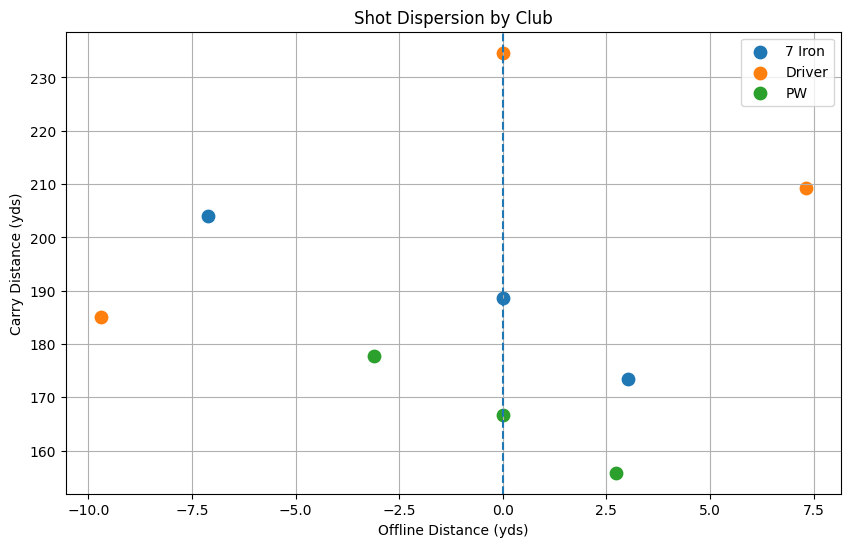

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for club, group in df.groupby("club_name"):
    plt.scatter(group["carry_y_yds"], group["carry_x_yds"], label=club, s=80)

plt.axvline(0, linestyle="--")
plt.xlabel("Offline Distance (yds)")
plt.ylabel("Carry Distance (yds)")
plt.title("Shot Dispersion by Club")
plt.legend()
plt.grid(True)
plt.show()

Monte Carlo Sim

In [108]:
sim_data = []

for club_name, group in df.groupby("club_name"):
    representative_row = group.mean(numeric_only=True)
    representative_row["club_name"] = club_name
    sims = simulate_shots(representative_row, n=200)

    for x, y in sims:
        sim_data.append({
            "club": club_name,
            "carry_x_m": x,
            "carry_y_m": y
        })

sim_df = pd.DataFrame(sim_data)
sim_df.head()

,club,carry_x_m,carry_y_m
0,7 Iron,178.170681,-2.229794
1,7 Iron,180.792331,-2.691021
2,7 Iron,176.040669,-8.690529
3,7 Iron,172.171604,1.834594
4,7 Iron,193.075421,-6.719202


Distance Conversions

In [109]:
sim_df["carry_x_yds"] = sim_df["carry_x_m"] * METERS_TO_YARDS
sim_df["carry_y_yds"] = sim_df["carry_y_m"] * METERS_TO_YARDS

Club Summary Table

In [110]:
club_summary = summarize_by_club(sim_df)
club_summary

,club,avg_carry_yds,std_carry_yds,avg_offline_yds,std_offline_yds,shot_count
0,7 Iron,190.589263,13.950573,-1.843572,3.839298,200
1,Driver,232.654330,17.441638,-2.088731,4.475278,200
2,PW,158.097621,11.217175,-0.504342,3.326186,200


Save as .csv file to outputs folder

In [111]:
club_summary.to_csv("../outputs/club_summary.csv", index=False)

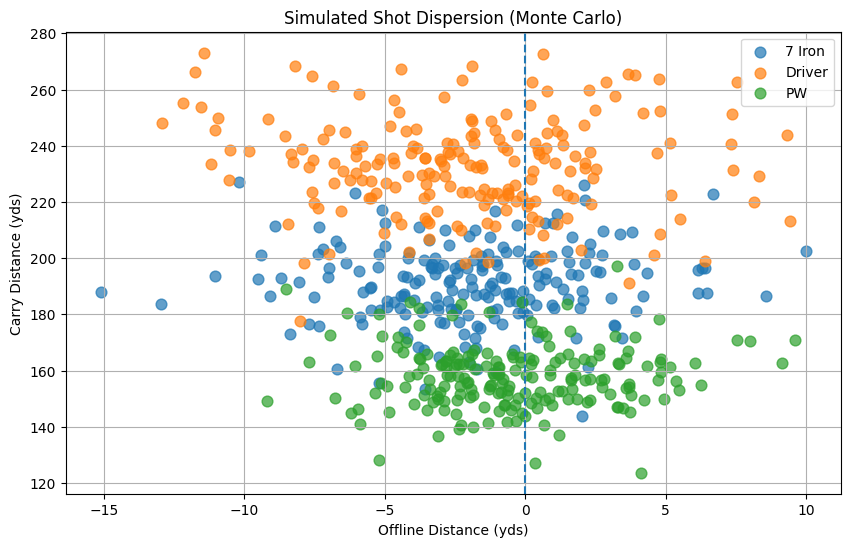

In [112]:
plt.figure(figsize=(10, 6))

for club, group in sim_df.groupby("club"):
    plt.scatter(group["carry_y_yds"], group["carry_x_yds"], label=club, alpha=0.7, s=60)

plt.axvline(0, linestyle="--")
plt.xlabel("Offline Distance (yds)")
plt.ylabel("Carry Distance (yds)")
plt.title("Simulated Shot Dispersion (Monte Carlo)")
plt.legend()
plt.grid(True)
plt.show()